# Skills Exercise Week 6
---
**Author:** Jay Ballesteros
**Due date:** May 1st, 2026

## 1.1 File Setup

Create a Jupyter Notebook for your skills assignment, with a file extension of .ipynb
- Make the first cell a markdown cell, and put in the name of the assignment, your name, and the due date.
- The second cell should be your imports for the assignment. In this case, pandas, matplotlib, and os. Do not put imports anywhere else in your assignment!

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight') #https://matplotlib.org/stable/gallery/style_sheets/fivethirtyeight.html

## 2.1 Loading Data

Load the Diamonds data from the diamonds.csv file (available on Canvas) into a Pandas DataFrame with a descriptive name (e.g., df diamonds)

In [2]:
PATH = ("/Users/jayballesteros/_github/uchicago-mpp/3_spring_2026/data_programming/skills-psets/_data")
print(PATH)

df_diamonds = pd.read_csv(os.path.join(PATH, "diamonds.csv"))

/Users/jayballesteros/_github/uchicago-mpp/3_spring_2026/data_programming/skills-psets/_data


## 2.2 Exploratory Data Analysis: 
Show code of your basic exploration of the data, and answer the following:


### How many rows and columns does the data have?
Running the `df_diamonds.shape` I get 53940 rows and 10 columns

In [3]:
df_diamonds.shape

(53940, 10)

### Do any of the rows or columns have missing values?
None. By implementing `df_diamonds.isna().sum()`I get 0 missing values for all 10 existing columns

In [4]:
df_diamonds.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

#### Which columns are non-numeric, and what are the unique values in each?
Mapping with `df_diamonds.dtypes` I got that the only non-numeric columns are `cut`, `color` and `clarity`. The three of them are an object.
The unique values for this columns are:
| Columns | Unique values |
|:--------------------|:--------------|
| `cut`               | ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair'] |
| `color`             | ['E' 'I' 'J' 'H' 'F' 'G' 'D'] |
| `clarity`           | ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF'] |

In [5]:
df_diamonds.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [6]:
print(df_diamonds["cut"].unique())
print(df_diamonds["color"].unique())
print(df_diamonds["clarity"].unique())

['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
['E' 'I' 'J' 'H' 'F' 'G' 'D']
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


### What does each row of the data represent?
If I have to take I guess, I'll say that each row is a specific diamond.

In [7]:
df_diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 2.3 Price Within Groups: There are eight different values for the “clarity” column.


### First, calculate the mean price for all of the observations.
Mean `price` is 3932.8

In [8]:
print(df_diamonds["price"].mean().round(2))

3932.8


### Next, calculate the mean price for each of the clarity groups. As we were last week, write a for-loop with subsetting to report the eight different mean values in print functions.


In [9]:


clarity = ['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']

for clar in clarity:
    clarity_filter = df_diamonds.loc[df_diamonds["clarity"] == clar]
    calculated_means = clarity_filter["price"].mean()
    print(f"Clarity: {clar}, {round(calculated_means, 2)}")

Clarity: SI2, 5063.03
Clarity: SI1, 3996.0
Clarity: VS1, 3839.46
Clarity: VS2, 3924.99
Clarity: VVS2, 3283.74
Clarity: VVS1, 2523.11
Clarity: I1, 3924.17
Clarity: IF, 2864.84


### Now that we know how to use groupby, we have an easier way! Report the same eight mean values using a single groupby operation.

In [10]:
df_diamonds.groupby("clarity")["price"].mean().round(2)

clarity
I1      3924.17
IF      2864.84
SI1     3996.00
SI2     5063.03
VS1     3839.46
VS2     3924.99
VVS1    2523.11
VVS2    3283.74
Name: price, dtype: float64

## 2.4 Custom Sorting Order: It is hard to interpret the mean values across the clarity groups, because it isn’t obvious to someone untrained in grading diamonds which clarity is better than another.

### First, create a new DataFrame equal to the result of grouping by clarity and showing the mean value for all numeric columns (it should have 8 rows and 8 columns, or 7 if you leave clarity in the index)

In [11]:
df_diamonds.groupby("clarity")["price"].mean().round(2)

clarity
I1      3924.17
IF      2864.84
SI1     3996.00
SI2     5063.03
VS1     3839.46
VS2     3924.99
VVS1    2523.11
VVS2    3283.74
Name: price, dtype: float64

In [12]:
df_diamonds.groupby("clarity")["price"].mean().round(2)

clarity
I1      3924.17
IF      2864.84
SI1     3996.00
SI2     5063.03
VS1     3839.46
VS2     3924.99
VVS1    2523.11
VVS2    3283.74
Name: price, dtype: float64

In [13]:
df_diamonds.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [14]:
calc_means = {'carat':'mean', 'depth':'mean', 'table':'mean', 'price':'mean', 'x':'mean', 'y':'mean', 'z':'mean'} # https://stackoverflow.com/questions/47360510/pandas-groupby-and-aggregation-output-should-include-all-the-original-columns-i

df_gmeans = df_diamonds.groupby(['clarity'], as_index=False).agg(calc_means).round(2)

print(df_gmeans)

  clarity  carat  depth  table    price     x     y     z
0      I1   1.28  62.73  58.30  3924.17  6.76  6.71  4.21
1      IF   0.51  61.51  56.51  2864.84  4.97  4.99  3.06
2     SI1   0.85  61.85  57.66  3996.00  5.89  5.89  3.64
3     SI2   1.08  61.77  57.93  5063.03  6.40  6.40  3.95
4     VS1   0.73  61.67  57.32  3839.46  5.57  5.58  3.44
5     VS2   0.76  61.72  57.42  3924.99  5.66  5.66  3.49
6    VVS1   0.50  61.62  56.88  2523.11  4.96  4.98  3.06
7    VVS2   0.60  61.66  57.02  3283.74  5.22  5.23  3.22


### Sort the values in descending order of clarity. How did this sort the data, and was it helpful?

Not really. Order looks weird since it seems to be considering alphabetical order. Therefore, maybe it would be more valuable if is organized by quantitative information. For instance, price.

In [15]:
df_gmeans.sort_values(by="clarity", ascending=False)

,clarity,carat,depth,table,price,x,y,z
7,VVS2,0.60,61.66,57.02,3283.74,5.22,5.23,3.22
6,VVS1,0.50,61.62,56.88,2523.11,4.96,4.98,3.06
5,VS2,0.76,61.72,57.42,3924.99,5.66,5.66,3.49
4,VS1,0.73,61.67,57.32,3839.46,5.57,5.58,3.44
3,SI2,1.08,61.77,57.93,5063.03,6.40,6.40,3.95
2,SI1,0.85,61.85,57.66,3996.00,5.89,5.89,3.64
1,IF,0.51,61.51,56.51,2864.84,4.97,4.99,3.06
0,I1,1.28,62.73,58.30,3924.17,6.76,6.71,4.21


### The correct order from worst to best is: I3, I2, I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF, FL. Look up in the official documentation how to create a custom sorting order using the pd.Categorical class, and apply it to the clarity column. You should do this on the full data, then redo your creation of df clarity. Then redo your sorting so that sort values puts your data in a meaningful order.

In [16]:
#  unique values of clarity ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']. adding FL, I2 and I3 was messsing with 2.4 

order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

df_diamonds["clarity"] = pd.Categorical(df_diamonds["clarity"], order) #https://stackoverflow.com/questions/13838405/custom-sorting-in-pandas-dataframe

df_diamonds = df_diamonds.sort_values("clarity")

calc_means = {'carat':'mean', 'depth':'mean', 'table':'mean', 'price':'mean', 'x':'mean', 'y':'mean', 'z':'mean'}

df_gmeans = df_diamonds.groupby(['clarity'], as_index=False).agg(calc_means).round(2)

print(df_gmeans)

  clarity  carat  depth  table    price     x     y     z
0      I1   1.28  62.73  58.30  3924.17  6.76  6.71  4.21
1     SI2   1.08  61.77  57.93  5063.03  6.40  6.40  3.95
2     SI1   0.85  61.85  57.66  3996.00  5.89  5.89  3.64
3     VS2   0.76  61.72  57.42  3924.99  5.66  5.66  3.49
4     VS1   0.73  61.67  57.32  3839.46  5.57  5.58  3.44
5    VVS2   0.60  61.66  57.02  3283.74  5.22  5.23  3.22
6    VVS1   0.50  61.62  56.88  2523.11  4.96  4.98  3.06
7      IF   0.51  61.51  56.51  2864.84  4.97  4.99  3.06


/var/folders/8p/mzh9p8r52s795vp2hwtly6t40000gn/T/ipykernel_79380/1009602307.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_gmeans = df_diamonds.groupby(['clarity'], as_index=False).agg(calc_means).round(2)


## 2.5. Solving the Price Mystery: The best category of clarity (in our dataset), IF, does not have the highest average price. In fact, we have to go all the way to SI2 for the highest average price, and this may be particularly puzzling, because the SI2 clarity group doesn’t even have the highest average value of carat (weight)!

### We can’t use groupby on a continuous variable directly, so instead we will split carat into two categories. Using the map method and an anonymous function on the full data (not the clarity subset), create a dummy variable that is equal to 1 if “carat” is greater than 1, else 0 if “carat” is equal to or less than 1. Assign this to a new column named “>1ct”.

In [17]:
df_diamonds[">1ct"] = df_diamonds["carat"].map(lambda x: 1 if x > 1 else 0) # https://stackoverflow.com/questions/29247718/map-an-if-statement-in-python

### Create a new DataFrame named counts that is equal to the number of observations in each group, when grouping by both “clarity” and “>1ct”. Its shape should be (16, 9) if you leave the grouping keys in the index.

In [18]:
counts = df_diamonds.groupby(["clarity", ">1ct"]).count()

/var/folders/8p/mzh9p8r52s795vp2hwtly6t40000gn/T/ipykernel_79380/130419078.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_diamonds.groupby(["clarity", ">1ct"]).count()


In [19]:
print(counts.shape)

(16, 9)


In [20]:
print(counts)

              carat   cut  color  depth  table  price     x     y     z
clarity >1ct                                                           
I1      0       248   248    248    248    248    248   248   248   248
        1       493   493    493    493    493    493   493   493   493
SI2     0      4297  4297   4297   4297   4297   4297  4297  4297  4297
        1      4897  4897   4897   4897   4897   4897  4897  4897  4897
SI1     0      8483  8483   8483   8483   8483   8483  8483  8483  8483
        1      4582  4582   4582   4582   4582   4582  4582  4582  4582
VS2     0      8575  8575   8575   8575   8575   8575  8575  8575  8575
        1      3683  3683   3683   3683   3683   3683  3683  3683  3683
VS1     0      5935  5935   5935   5935   5935   5935  5935  5935  5935
        1      2236  2236   2236   2236   2236   2236  2236  2236  2236
VVS2    0      4090  4090   4090   4090   4090   4090  4090  4090  4090
        1       976   976    976    976    976    976   976   97

In [21]:
counts

carat   cut  color  depth  table  price     x     y     z
clarity >1ct                                                           
I1      0       248   248    248    248    248    248   248   248   248
        1       493   493    493    493    493    493   493   493   493
SI2     0      4297  4297   4297   4297   4297   4297  4297  4297  4297
        1      4897  4897   4897   4897   4897   4897  4897  4897  4897
SI1     0      8483  8483   8483   8483   8483   8483  8483  8483  8483
        1      4582  4582   4582   4582   4582   4582  4582  4582  4582
VS2     0      8575  8575   8575   8575   8575   8575  8575  8575  8575
        1      3683  3683   3683   3683   3683   3683  3683  3683  3683
VS1     0      5935  5935   5935   5935   5935   5935  5935  5935  5935
        1      2236  2236   2236   2236   2236   2236  2236  2236  2236
VVS2    0      4090  4090   4090   4090   4090   4090  4090  4090  4090
        1       976   976    976    976    976    976   976   976   976
VVS1    0      3259  3259   3259   3259   3259   3259  3259  3259  3259
        1       396   396    396    396    396    396   396   396   396
IF      0      1551  1551   1551   1551   1551   1551  1551  1551  1551
        1       239   239    239    239    239    239   239   239   239

### Now note that the columns in counts are redundant, since the number of observations in each is the same. Filter the counts DataFrame to a single column (besides the grouping keys), and rename that column to “counts”.

In [22]:
counts = counts[["carat"]].rename(columns={"carat": "counts"})

In [23]:
counts

counts
clarity >1ct        
I1      0        248
        1        493
SI2     0       4297
        1       4897
SI1     0       8483
        1       4582
VS2     0       8575
        1       3683
VS1     0       5935
        1       2236
VVS2    0       4090
        1        976
VVS1    0       3259
        1        396
IF      0       1551
        1        239

### Next make another DataFrame named “df cl wgt” that is equal to the the original data grouped by both “clarity” and “>1ct”, aggregated by mean values.

In [24]:
df_cl_wgt = df_diamonds.groupby(["clarity", ">1ct"]).agg(calc_means).round(2)

/var/folders/8p/mzh9p8r52s795vp2hwtly6t40000gn/T/ipykernel_79380/904388882.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cl_wgt = df_diamonds.groupby(["clarity", ">1ct"]).agg(calc_means).round(2)


In [25]:
df_cl_wgt

carat  depth  table     price     x     y     z
clarity >1ct                                                 
I1      0      0.76  62.99  58.55   1589.33  5.76  5.69  3.61
        1      1.55  62.61  58.18   5098.69  7.26  7.22  4.51
SI2     0      0.68  61.80  57.72   2126.23  5.55  5.55  3.43
        1      1.43  61.75  58.11   7640.00  7.15  7.15  4.41
SI1     0      0.59  61.87  57.53   1910.55  5.28  5.29  3.27
        1      1.34  61.82  57.91   7856.96  7.01  7.00  4.33
VS2     0      0.52  61.72  57.26   1762.33  5.08  5.08  3.14
        1      1.33  61.73  57.79   8960.23  7.01  7.00  4.32
VS1     0      0.51  61.68  57.19   1759.92  5.04  5.05  3.12
        1      1.31  61.64  57.64   9359.16  6.99  6.98  4.30
VVS2    0      0.45  61.66  56.98   1629.85  4.83  4.85  2.98
        1      1.22  61.69  57.21  10214.46  6.84  6.85  4.22
VVS1    0      0.42  61.63  56.84   1489.23  4.73  4.75  2.92
        1      1.22  61.55  57.24  11031.82  6.83  6.84  4.20
IF      0      0.40  61.52  56.35   1482.02  4.69  4.71  2.89
        1      1.20  61.43  57.51  11838.72  6.81  6.83  4.19

### Assign the DataFrame you named counts to a column in this new data named “counts”

In [26]:
df_cl_wgt["counts"] = counts["counts"]

In [27]:
df_cl_wgt

carat  depth  table     price     x     y     z  counts
clarity >1ct                                                         
I1      0      0.76  62.99  58.55   1589.33  5.76  5.69  3.61     248
        1      1.55  62.61  58.18   5098.69  7.26  7.22  4.51     493
SI2     0      0.68  61.80  57.72   2126.23  5.55  5.55  3.43    4297
        1      1.43  61.75  58.11   7640.00  7.15  7.15  4.41    4897
SI1     0      0.59  61.87  57.53   1910.55  5.28  5.29  3.27    8483
        1      1.34  61.82  57.91   7856.96  7.01  7.00  4.33    4582
VS2     0      0.52  61.72  57.26   1762.33  5.08  5.08  3.14    8575
        1      1.33  61.73  57.79   8960.23  7.01  7.00  4.32    3683
VS1     0      0.51  61.68  57.19   1759.92  5.04  5.05  3.12    5935
        1      1.31  61.64  57.64   9359.16  6.99  6.98  4.30    2236
VVS2    0      0.45  61.66  56.98   1629.85  4.83  4.85  2.98    4090
        1      1.22  61.69  57.21  10214.46  6.84  6.85  4.22     976
VVS1    0      0.42  61.63  56.84   1489.23  4.73  4.75  2.92    3259
        1      1.22  61.55  57.24  11031.82  6.83  6.84  4.20     396
IF      0      0.40  61.52  56.35   1482.02  4.69  4.71  2.89    1551
        1      1.20  61.43  57.51  11838.72  6.81  6.83  4.19     239

### Look at just the grouping keys (“clarity” and “>1ct”) and the “price” and “counts” columns. Which group has the largest price now?

By sorting values of `df_cl_wgt["price"]`, I get that IF with carat > 1 has the largets price now: 11,838.72.

In [28]:
df_cl_wgt["price"].sort_values(ascending=False)

clarity  >1ct
IF       1       11838.72
VVS1     1       11031.82
VVS2     1       10214.46
VS1      1        9359.16
VS2      1        8960.23
SI1      1        7856.96
SI2      1        7640.00
I1       1        5098.69
SI2      0        2126.23
SI1      0        1910.55
VS2      0        1762.33
VS1      0        1759.92
VVS2     0        1629.85
I1       0        1589.33
VVS1     0        1489.23
IF       0        1482.02
Name: price, dtype: float64

### Create a new column in “df cl wgt” named “avg unit price” and set it equal to the “price” column divided by the “carat” column. Which three groups have the highest price per unit of carat weight? Which group has the highest average carat weight?

The groups with highest price per unit of carat weight are IF(1), VVS1(1) and VVS2(1). The group with highest average carat weight is SI2(1), that ranks in the last four in the sorting of `avg_unit_price`.

In [29]:
df_cl_wgt["avg_unit_price"] = df_cl_wgt["price"] / df_cl_wgt["carat"]

In [30]:
df_cl_wgt[["avg_unit_price", "carat"]].sort_values(by="avg_unit_price", ascending=False).round(2)

,,avg_unit_price,carat
clarity,>1ct,,
IF,1,9865.60,1.20
VVS1,1,9042.48,1.22
VVS2,1,8372.51,1.22
VS1,1,7144.40,1.31
VS2,1,6737.02,1.33
SI1,1,5863.40,1.34
SI2,1,5342.66,1.43
IF,0,3705.05,0.40
VVS2,0,3621.89,0.45


## 3.1 Exploring Other Relations: We looked at the relationship between clarity and weight, but there are more variables in this data! Next we will look at clarity and color.

### When trying to compare two categorical variables, we first need to know if the values have an ordinal meaning. Fortunately we’ve already worked out the details for clarity - explore the color column, and find out how what color values mean for diamonds.

In the diamonds world, colors are not necessarily a color, but a scale between colorless and ligth yellow (source: https://en.wikipedia.org/wiki/Diamond_color). 

Therefore, in the exisintg values of this dataframe, the scale goes like this (descending in terms of colorlessness and grade):

D: Colorless
E: Colorless
F; Colorless
G: Near colorless
H: Near colorless
I: Near colorless
J: Near colorless

Note: There are more letters corresponding to the scales of fain yellow, very light yellow and light yellow, that goes from the letter K to Z. Nonetheless none of this letters are available in our dataframe.

In [31]:
df_diamonds["color"].value_counts()

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

In [32]:
df_diamonds.groupby(["clarity", "color"]).count()

/var/folders/8p/mzh9p8r52s795vp2hwtly6t40000gn/T/ipykernel_79380/2569866895.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_diamonds.groupby(["clarity", "color"]).count()


carat   cut  depth  table  price     x     y     z  >1ct
clarity color                                                          
I1      D         42    42     42     42     42    42    42    42    42
        E        102   102    102    102    102   102   102   102   102
        F        143   143    143    143    143   143   143   143   143
        G        150   150    150    150    150   150   150   150   150
        H        162   162    162    162    162   162   162   162   162
        I         92    92     92     92     92    92    92    92    92
        J         50    50     50     50     50    50    50    50    50
SI2     D       1370  1370   1370   1370   1370  1370  1370  1370  1370
        E       1713  1713   1713   1713   1713  1713  1713  1713  1713
        F       1609  1609   1609   1609   1609  1609  1609  1609  1609
        G       1548  1548   1548   1548   1548  1548  1548  1548  1548
        H       1563  1563   1563   1563   1563  1563  1563  1563  1563
        I        912   912    912    912    912   912   912   912   912
        J        479   479    479    479    479   479   479   479   479
SI1     D       2083  2083   2083   2083   2083  2083  2083  2083  2083
        E       2426  2426   2426   2426   2426  2426  2426  2426  2426
        F       2131  2131   2131   2131   2131  2131  2131  2131  2131
        G       1976  1976   1976   1976   1976  1976  1976  1976  1976
        H       2275  2275   2275   2275   2275  2275  2275  2275  2275
        I       1424  1424   1424   1424   1424  1424  1424  1424  1424
        J        750   750    750    750    750   750   750   750   750
VS2     D       1697  1697   1697   1697   1697  1697  1697  1697  1697
        E       2470  2470   2470   2470   2470  2470  2470  2470  2470
        F       2201  2201   2201   2201   2201  2201  2201  2201  2201
        G       2347  2347   2347   2347   2347  2347  2347  2347  2347
        H       1643  1643   1643   1643   1643  1643  1643  1643  1643
        I       1169  1169   1169   1169   1169  1169  1169  1169  1169
        J        731   731    731    731    731   731   731   731   731
VS1     D        705   705    705    705    705   705   705   705   705
        E       1281  1281   1281   1281   1281  1281  1281  1281  1281
        F       1364  1364   1364   1364   1364  1364  1364  1364  1364
        G       2148  2148   2148   2148   2148  2148  2148  2148  2148
        H       1169  1169   1169   1169   1169  1169  1169  1169  1169
        I        962   962    962    962    962   962   962   962   962
        J        542   542    542    542    542   542   542   542   542
VVS2    D        553   553    553    553    553   553   553   553   553
        E        991   991    991    991    991   991   991   991   991
        F        975   975    975    975    975   975   975   975   975
        G       1443  1443   1443   1443   1443  1443  1443  1443  1443
        H        608   608    608    608    608   608   608   608   608
        I        365   365    365    365    365   365   365   365   365
        J        131   131    131    131    131   131   131   131   131
VVS1    D        252   252    252    252    252   252   252   252   252
        E        656   656    656    656    656   656   656   656   656
        F        734   734    734    734    734   734   734   734   734
        G        999   999    999    999    999   999   999   999   999
        H        585   585    585    585    585   585   585   585   585
        I        355   355    355    355    355   355   355   355   355
        J         74    74     74     74     74    74    74    74    74
IF      D         73    73     73     73     73    73    73    73    73
        E        158   158    158    158    158   158   158   158   158
        F        385   385    385    385    385   385   385   385   385
        G        681   681    681    681    681   681   681   681   681
        H        299   299    299    299    299   299  

### Use groupby to check the mean prices within the different combinations of color and clarity. Make sure you are sorting.

In [33]:
df_diamonds.groupby(["color", "clarity"])["price"].mean().round(2).sort_values(ascending=False)

/var/folders/8p/mzh9p8r52s795vp2hwtly6t40000gn/T/ipykernel_79380/3687429835.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_diamonds.groupby(["color", "clarity"])["price"].mean().round(2).sort_values(ascending=False)


color  clarity
D      IF         8307.37
I      SI2        7002.65
J      SI2        6520.96
H      SI2        6099.90
I      VS2        5690.51
       SI1        5355.02
J      VS2        5311.06
       I1         5254.06
       SI1        5186.05
       VVS2       5142.40
H      SI1        5032.41
G      SI2        5021.68
J      VS1        4884.46
H      VS2        4722.41
I      VS1        4633.18
F      SI2        4472.63
H      I1         4453.41
G      VS2        4416.26
I      I1         4302.18
E      SI2        4173.83
G      VS1        4131.36
J      VVS1       4034.18
D      SI2        3931.10
       I1         3863.02
G      VVS2       3845.28
F      VS1        3796.72
H      VS1        3780.69
G      SI1        3774.79
F      VS2        3756.80
       SI1        3714.23
E      IF         3668.51
G      I1         3545.69
E      I1         3488.42
F      VVS2       3475.51
J      IF         3363.88
D      VVS2       3351.13
F      I1         3342.18
E      SI1        3161.

## 3.2 Creating a Heatmap: When comparing two ordered, categorical values, one logical solution is a heatmap.

### The Seaborn library is an API that returns Matplotlib axis objects that it sets up for you. It was installed as part of our requirements.txt file in week 1 - add import seaborn as sns to the top of your file.

### A heatmap is created by having one variable down the index, and the other across the columns, with the cells at each intersection of an index and a column representing the value for that combination. Reshape the diamonds data so that there are 8 rows, one for each clarity category, and 7 columns, one for each color category. The values should be the mean price for all observations of that clarity-color combination.

In [34]:
df_col_cla = df_diamonds.groupby(["color", "clarity"])["price"].mean().round(2).sort_values(ascending=False).reset_index()


/var/folders/8p/mzh9p8r52s795vp2hwtly6t40000gn/T/ipykernel_79380/3735767603.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_col_cla = df_diamonds.groupby(["color", "clarity"])["price"].mean().round(2).sort_values(ascending=False).reset_index()


In [35]:
df_col_cla

,color,clarity,price
0,D,IF,8307.37
1,I,SI2,7002.65
2,J,SI2,6520.96
3,H,SI2,6099.90
4,I,VS2,5690.51
5,I,SI1,5355.02
6,J,VS2,5311.06
7,J,I1,5254.06
8,J,SI1,5186.05
9,J,VVS2,5142.40


In [45]:
df_col_cla["clarity"] = pd.Categorical(df_col_cla["clarity"], categories=order, ordered=True)
df_col_cla = df_col_cla.sort_values("clarity")

df_wide = df_col_cla.pivot(index="clarity", columns="color", values="price")

In [46]:
df_wide

color,D,E,F,G,H,I,J
clarity,,,,,,,
I1,3863.02,3488.42,3342.18,3545.69,4453.41,4302.18,5254.06
SI2,3931.10,4173.83,4472.63,5021.68,6099.90,7002.65,6520.96
SI1,2976.15,3161.84,3714.23,3774.79,5032.41,5355.02,5186.05
VS2,2587.23,2750.94,3756.80,4416.26,4722.41,5690.51,5311.06
VS1,3030.16,2856.29,3796.72,4131.36,3780.69,4633.18,4884.46
VVS2,3351.13,2499.67,3475.51,3845.28,2649.07,2968.23,5142.40
VVS1,2947.91,2219.82,2804.28,2866.82,1845.66,2034.86,4034.18
IF,8307.37,3668.51,2750.84,2558.03,2287.87,1994.94,3363.88


### Use that wide data with the sns.heatmap function to see the relationship between color and clarity. Make sure your axis are sorted logically so the flow of the heatmap colors makes sense!

<Axes: xlabel='color', ylabel='clarity'>

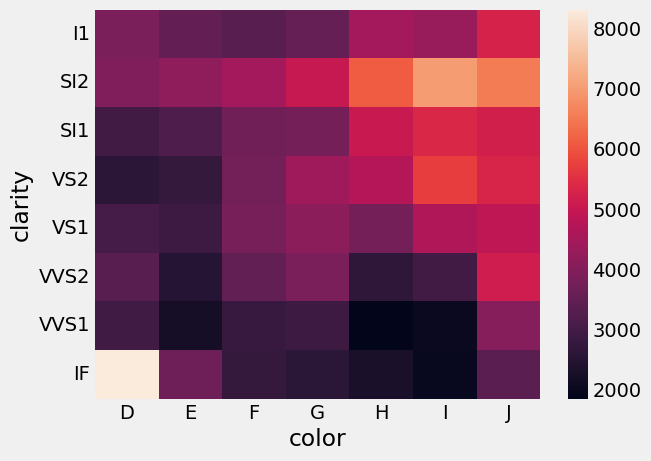

In [51]:
sns.heatmap(df_wide)

## 3.3 Exploring Outliers: The heatmap should make a major outlier clear, at the intersection of the best of both categories (D, IF).

### One option is that an “unobserved” (to this figure) value is affecting the prices. A heatmap doesn’t do a good job showing two continuous variables as values, unless we can interact them and show just the result! Calculate a new column, “price per carat”, that is equal to “price” divided by “carat” for each individual diamond. Re-create the heatmap with this as the values, instead of “price”.

In [ ]:
df_diamonds["pice_per_carat"] = df_diamonds["price"] / df_diamonds["carat"]

df_col_cla = df_diamonds.groupby(["color", "clarity"])["pice_per_carat"].mean().round(2).sort_values(ascending=False).reset_index()

/var/folders/8p/mzh9p8r52s795vp2hwtly6t40000gn/T/ipykernel_79380/1440555201.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_col_cla = df_diamonds.groupby(["color", "clarity"])["pice_per_carat"].mean().round(2).sort_values(ascending=False).reset_index()


### This new heatmap shows a smoother transition along the rankings, but we still see a significant outlier at the intersection of the two “best” values (IF, D). What does this say about the behavior of diamond buyers?

In [53]:
df_col_cla["clarity"] = pd.Categorical(df_col_cla["clarity"], categories=order, ordered=True)
df_col_cla = df_col_cla.sort_values("clarity")

df_wide = df_col_cla.pivot(index="clarity", columns="color", values="pice_per_carat")

<Axes: xlabel='color', ylabel='clarity'>

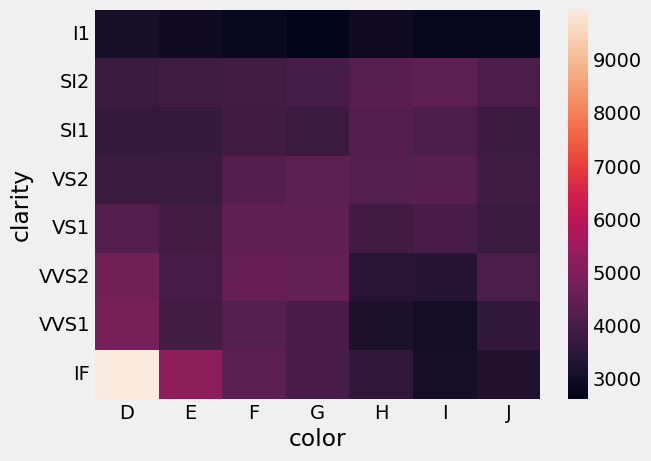

In [54]:
sns.heatmap(df_wide)